In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [19]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [22]:
df=df.dropna(subset=["CustomerID"])
df= df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df=df[df["Quantity"]>0]
df=df[df["UnitPrice"]>0]
df["TotalAmount"]=df["Quantity"]*df["UnitPrice"]
print(df.shape)
print(df.head)

(397884, 9)
<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitP

In [26]:
customer_data = df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    NumberOfProducts=("StockCode", "nunique"),
    AverageOrderValue=("TotalAmount", "mean"),
    Country=("Country", "first")
).reset_index()

print(customer_data.head())

   CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0     12346.0    77183.60          74215                     1   
1     12347.0     4310.00           2458                     7   
2     12348.0     1797.24           2341                     4   
3     12349.0     1757.55            631                     1   
4     12350.0      334.40            197                     1   

   NumberOfProducts  AverageOrderValue         Country  
0                 1       77183.600000  United Kingdom  
1               103          23.681319         Iceland  
2                22          57.975484         Finland  
3                73          24.076027           Italy  
4                17          19.670588          Norway  


In [30]:
customer_data["Segment"]=pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)
print(customer_data["Segment"].value_counts())



Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64


In [36]:
features=[
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]

x=customer_data[features]
y=customer_data["Segment"]

In [42]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
id3_model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)
id3_model.fit(x_train,y_train)
y_pred=id3_model.predict(x_test)
print("Predictions:")
print(y_pred[:20])

    
    

Predictions:
['Low Value' 'Low Value' 'Low Value' 'Low Value' 'Medium Value'
 'Low Value' 'Low Value' 'High Value' 'Low Value' 'Medium Value'
 'Low Value' 'Medium Value' 'High Value' 'High Value' 'High Value'
 'High Value' 'Low Value' 'Low Value' 'High Value' 'Low Value']


In [43]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8467741935483871

Classification Report:
              precision    recall  f1-score   support

  High Value       0.93      0.87      0.90       289
   Low Value       0.87      0.85      0.86       289
Medium Value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868


Confusion Matrix:
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


Text(0.5, 1.0, 'CustomerSegmentations using ID# Decision Tree')

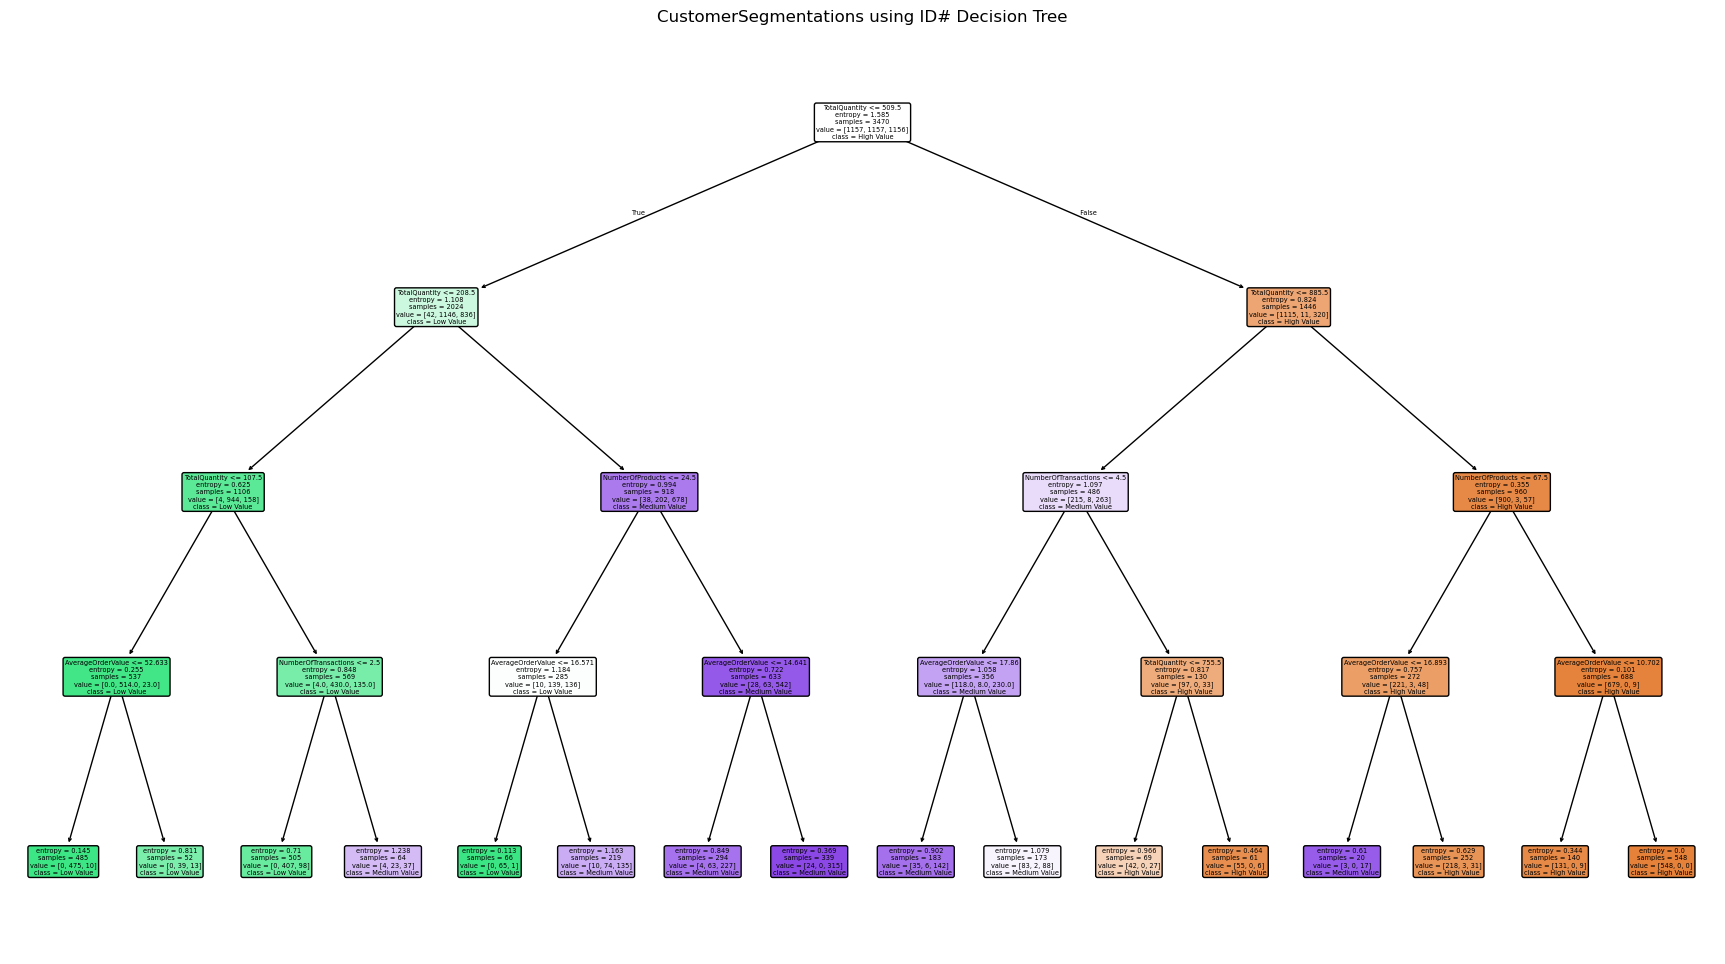

In [51]:
importance= pd.DataFrame({
    "Feature":features,
    "importance":id3_model.feature_importances_
})
importance_sorted=importance.sort_values(
    "importance",
    ascending=True
)
plt.figure(figsize=(22,12))
plot_tree(
    id3_model,
    feature_names=features,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    proportion=False
)
plt.title("CustomerSegmentations using ID3 Decision Tree")
plt.show()
           


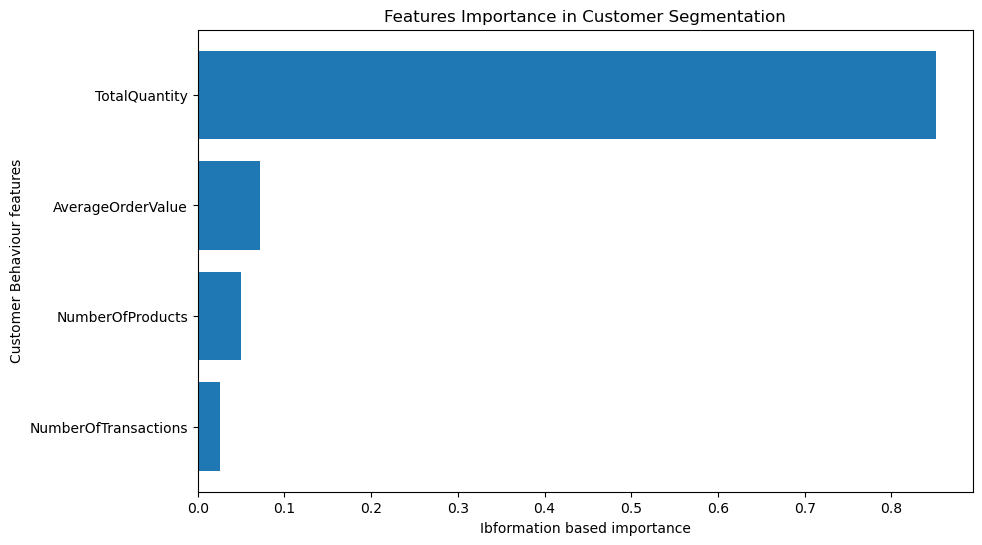

In [52]:
plt.figure(figsize=(10,6))
importance_sorted=importance.sort_values(
    "importance",
    ascending=True
)
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["importance"]
)
plt.xlabel("Ibformation based importance")
plt.ylabel("Customer Behaviour features")
plt.title("Features Importance in Customer Segmentation")
plt.show()